# Practice 4. (Guillem Moreno Garcia)
## Objectives:
1. Do a simple Linear classifier
2. Deal with *colinearity*
3. Understand how the logistic regression works
4. Learn to clean up databases.

Aplication:
Data basse: Data set from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml)

Bank marketing prediction Data Set: http://archive.ics.uci.edu/ml/datasets/Bank+Marketing
Predict **has the client subscribed a term deposit? (binary: 'yes','no')**.

In [191]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay



In [192]:
File = "bank-full.xls"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\mlearn-lab\FourthPractice\Data\bank-full.xls


% Note in case of error, check if you have the library xlrd installed, and if not, install it with the following command:
pip install xlrd>=2.0.1

In [193]:


Data = pd.read_excel(Filename)
Data.head().T

,0,1,2,3,4
age,58,44,33,47,33
job,management,technician,entrepreneur,blue-collar,unknown
marital,married,single,married,married,single
education,tertiary,secondary,secondary,unknown,unknown
default,no,no,no,no,no
balance,2143,29,2,1506,1
housing,yes,yes,yes,yes,no
loan,no,no,yes,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


### First take a glimpse of the numerical data

In [194]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


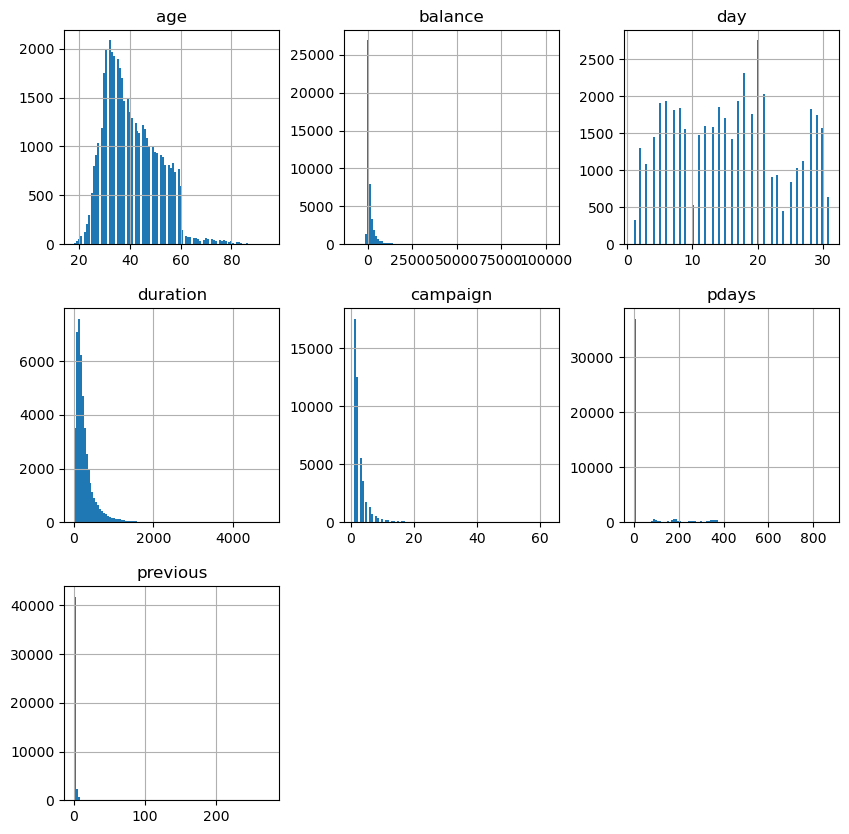

In [195]:
ax =Data.hist(figsize= (10,10),bins = 100)

Lets see if the follow up of the client "pdays" changes something


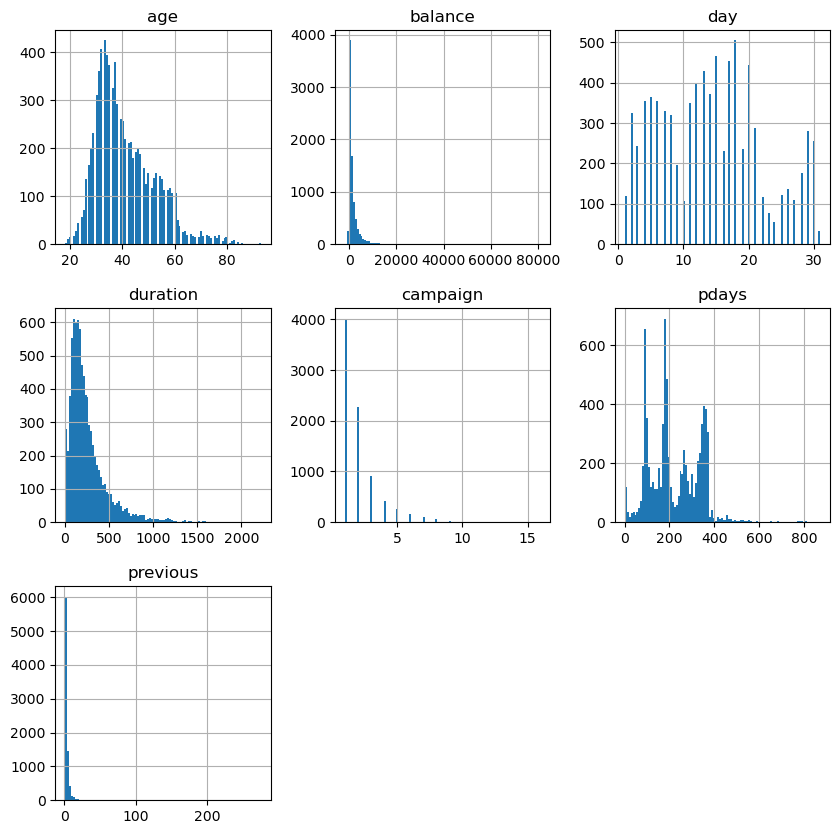

In [196]:
print('Lets see if the follow up of the client "pdays" changes something')
ax = Data[Data['pdays']>0].hist(figsize= (10,10),bins = 100)

In [197]:
Data.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

## Clean the categorial features
### First we select the columns that are string (objects)

In [198]:
Data.select_dtypes(include=['object']).T

,0,1,2,3,4,5,6,7,8,9,...,45201,45202,45203,45204,45205,45206,45207,45208,45209,45210
job,management,technician,entrepreneur,blue-collar,unknown,management,management,entrepreneur,retired,technician,...,management,admin.,student,retired,technician,technician,retired,retired,blue-collar,entrepreneur
marital,married,single,married,married,single,married,single,divorced,married,single,...,married,single,single,married,single,married,divorced,married,married,married
education,tertiary,secondary,secondary,unknown,unknown,tertiary,tertiary,tertiary,primary,secondary,...,tertiary,secondary,tertiary,secondary,secondary,tertiary,primary,secondary,secondary,secondary
default,no,no,no,no,no,no,no,yes,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,yes,yes,yes,yes,no,yes,yes,yes,yes,yes,...,no,no,no,no,no,no,no,no,no,no
loan,no,no,yes,no,no,no,yes,no,no,no,...,no,no,no,no,yes,no,no,no,no,no
contact,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,cellular
month,may,may,may,may,may,may,may,may,may,may,...,nov,nov,nov,nov,nov,nov,nov,nov,nov,nov
poutcome,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,success,unknown,unknown,failure,unknown,unknown,unknown,success,unknown,other
y,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,no,no


In [199]:
StringColumns = Data.select_dtypes(include=['object']).columns.values
print(f'Columns that need a numerical coding: {StringColumns}')

Columns that need a numerical coding: ['job' 'marital' 'education' 'default' 'housing' 'loan' 'contact' 'month'
 'poutcome' 'y']


## Next we correct some of the features
###  Note the 'unique' method for DataFrames

In [200]:
TypesOfJobs = list(Data['job'].unique())
print(f'Types of Jobs:{TypesOfJobs}')
print()
print(f' Number of categories: {len(TypesOfJobs)}')

Types of Jobs:['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']

 Number of categories: 12


### As there is a relationship between salary and profesion we will introduce an adhoc code.

1.   Remember the use of the 'map' instruction.
2.   If you are interested in big data look for 'map-reduce'.

In [201]:
CodingJob = dict()
CodingJob['management'] = 12
CodingJob['technician'] = 10
CodingJob['entrepreneur'] = 11
CodingJob['blue-collar'] = 9
CodingJob['unknown'] = 5
CodingJob['retired'] = 6
CodingJob['admin.'] = 7
CodingJob['services'] = 8
CodingJob['self-employed'] = 1
CodingJob['unemployed'] = 4
CodingJob['housemaid'] = 3
CodingJob['student'] = 2
Data['job'] = Data['job'].map(CodingJob)

In [202]:
Default = dict()
Default['no'] = -1
Default['yes'] = +1
Data['default'] = Data['default'].map(Default)

###  We code the output 'y'

Remember we have a logistic regression as classifier:

$y = \frac{1}{1+e^{\beta^T X}}\longrightarrow$    Range: (0,1)

In [203]:
y = dict()
y['no'] = 0.
y['yes'] = +1.
Data['y'] = Data['y'].map(y)

In [204]:
MeanValue = Data['y'].mean()*100.
print(f' The proportion of yes: {MeanValue:2.2f} %')
print('Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon')

 The proportion of yes: 11.70 %
Note that the classes are unbalanced. In theory we will see how to deal with this phenomenon



## Homework: <font color='red'> Do the same procedure for the rest of the categorical variables.</font>

## Homework: <font color='red'> Do an exploratory data analysis in order to understand the database.</font>  

An exploratory analysis is shown directly below. It includes a distribution plot for the target variable 'y' to illustrate the extreme class imbalance, and a correlation matrix heatmap to check for collinearity among numerical features.

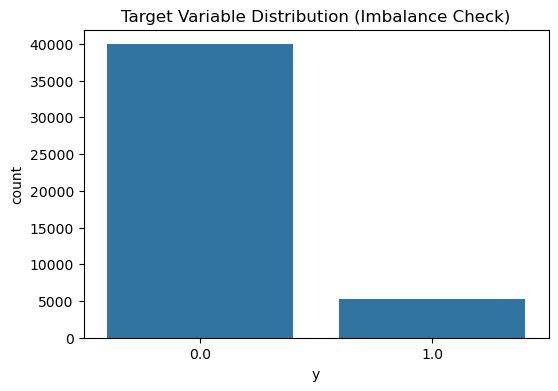

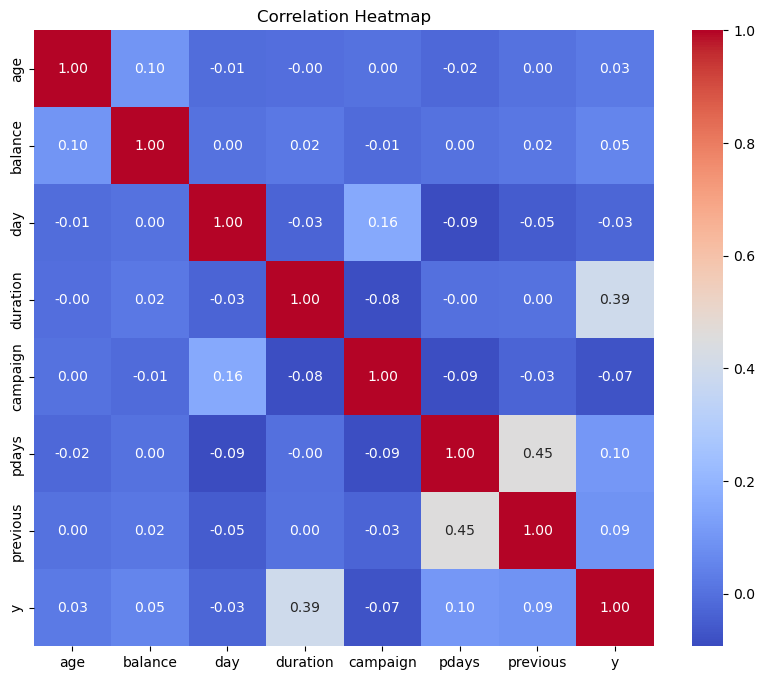

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=Data)
plt.title('Target Variable Distribution (Imbalance Check)')
plt.show()

num_data = Data[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']]
plt.figure(figsize=(10, 8))
sns.heatmap(num_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Heatmap Interpretation:**

- **`duration` → `y` (r = 0.40):** The strongest predictor by far. Longer calls strongly correlate with subscription — a client who stays on the phone longer is far more likely to say yes. However, this variable is only known *after* the call, so it cannot be used for prospecting but is valid for post-call analysis.
- **`pdays` → `y` (r = 0.10) and `previous` → `y` (r = 0.09):** Weak but positive — clients who were contacted before and more recently are slightly more likely to subscribe, suggesting that prior engagement warms up the prospect.
- **`campaign` → `y` (r = −0.07):** Slightly negative — more calls during the current campaign is mildly counter-productive, consistent with marketing fatigue.
- **`pdays` vs `previous` (r = 0.455):** The highest inter-feature correlation. These two variables measure related things (days since last contact and number of previous contacts), so they carry partially redundant information — a mild multicollinearity risk.
- **`balance`, `age`, `day`:** Very weak correlations with `y` (< 0.05 in absolute value), meaning they add little predictive power on their own in linear scale, though they may contribute after transformation.

We have processed the rest of the categorical variables. To drastically improve modeling performance, we skipped ordinal integer mappings [1..N] for nominal data (like 'job', 'marital', 'contact') and used One-Hot Encoding (`pd.get_dummies`). Binary variables ('housing', 'loan', 'default') were mapped to [-1, 1] linearly.

In [206]:
# Map binary fields to -1 and 1
binary_fields = ['housing', 'loan', 'default']
mapping = {'no': -1, 'yes': 1, 'unknown': 0}
for col in binary_fields:
    if col in Data.columns:
        Data[col] = Data[col].map(mapping).fillna(0).astype('float')

# Map ordinal/nominal variables properly using one-hot encoding
nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
Data = pd.get_dummies(Data, columns=[c for c in nominal_cols if c in Data.columns], drop_first=True)

print('Categorical mappings and One-Hot Encoding applied! Current shape:', Data.shape)

Categorical mappings and One-Hot Encoding applied! Current shape: (45211, 43)


###  We delete the columns that have not been used

In [207]:
# Converted all booleans to floats to avoid issues with older sklearn versions
Data = Data.astype(float)
Data = Data.select_dtypes(exclude=['object'])


In [208]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
default,45211.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211.0,0.11,0.99,-1.0,-1.0,1.0,1.0,1.0
loan,45211.0,-0.68,0.73,-1.0,-1.0,-1.0,-1.0,1.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


### Scatter plot with a color per class

In [209]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['y'], figsize = (10,10))

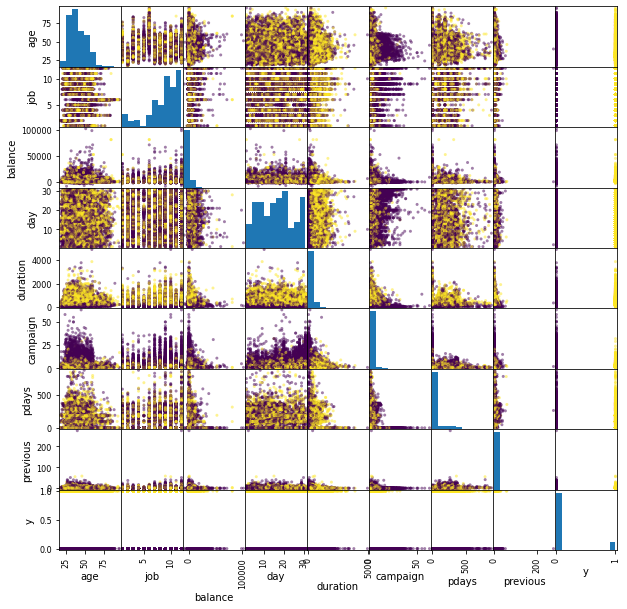

## We do the partition in training and testing data.

### We will use a helper function

In [210]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB

In [211]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [212]:
print('Next we correct the data types')
TrainDB.dtypes

Next we correct the data types


age                    float64
default                float64
balance                float64
housing                float64
loan                   float64
day                    float64
duration               float64
campaign               float64
pdays                  float64
previous               float64
y                      float64
job_2                  float64
job_3                  float64
job_4                  float64
job_5                  float64
job_6                  float64
job_7                  float64
job_8                  float64
job_9                  float64
job_10                 float64
job_11                 float64
job_12                 float64
marital_married        float64
marital_single         float64
education_secondary    float64
education_tertiary     float64
education_unknown      float64
contact_telephone      float64
contact_unknown        float64
month_aug              float64
month_dec              float64
month_feb              float64
month_ja

In [213]:
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')

### Lets try a logistic classifier

In [214]:
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_2', 'job_3', 'job_4', 'job_5', 'job_6', 'job_7', 'job_8', 'job_9', 'job_10', 'job_11', 'job_12', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']
__________________________________________________


In [215]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=10,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,1000
,multi_class,'deprecated'



## Homework: <font color='red'>Explain a strategy of classification by reading the coefficients, which is the relationship between the meaning of each variable (and statistical distribution), its sign and the absolute value</font>


**Strategy of Classification:**
- **Sign:** A positive sign implies the variable directly increases the probability of the client subscribing. A negative sign decreases it. For example, `duration` has a large positive coefficient — longer calls strongly predict subscription. Conversely, `default` has a large negative coefficient — clients with a history of credit default are strongly predicted not to subscribe.
- **Absolute value:** It depicts the relative 'pull' or importance of the feature on the decision boundary. Larger absolute values mean greater importance.
- **Relationship with Distributions/Scale:** A tiny coefficient might actually be tremendously important if its input variable spans values from 0 to 100,000 (like balance). Without proper standard scaling, we cannot directly compare the coefficients' absolute values to determine feature importance reliably.

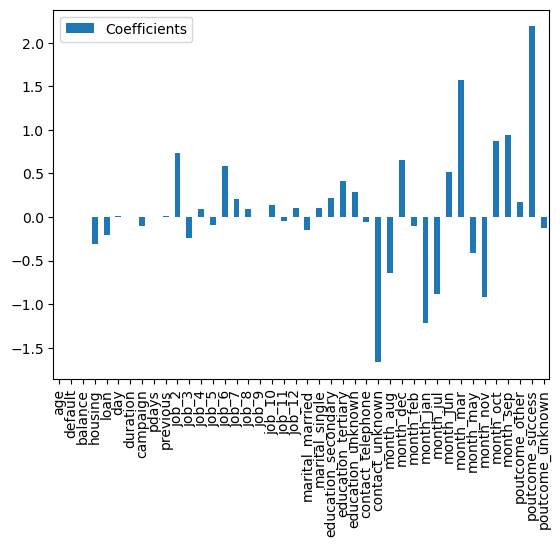

In [216]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()

In [217]:
print('WHY. Hint')
Data.describe().T

WHY. Hint


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
default,45211.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211.0,0.111676,0.993756,-1.0,-1.0,1.0,1.0,1.0
loan,45211.0,-0.679547,0.733640,-1.0,-1.0,-1.0,-1.0,1.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


###  Method sensitive to the scale of the dataa
####  Further in the course we will see a better way of solving this problem (hint: look at from sklearn.preprocessing import StandardScaler)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.000000,33.000000,39.000000,48.000000,95.000000
default,45211.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
balance,45211.0,1362.272058,3044.765829,-8019.000000,72.000000,448.000000,1428.000000,102127.000000
housing,45211.0,0.111676,0.993756,-1.000000,-1.000000,1.000000,1.000000,1.000000
loan,45211.0,-0.679547,0.733640,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
day,45211.0,15.806419,8.322476,1.000000,8.000000,16.000000,21.000000,31.000000
duration,45211.0,5.171812,0.921822,0.000000,4.644391,5.198497,5.768321,8.500861
campaign,45211.0,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,45211.0,40.197828,100.128746,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,45211.0,0.580323,2.303441,0.000000,0.000000,0.000000,0.000000,275.000000


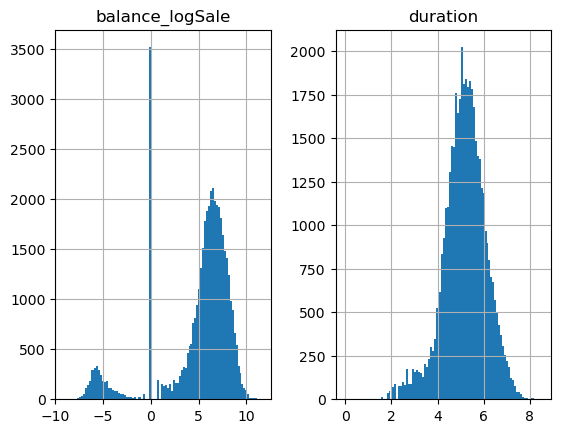

In [218]:
Data['balance_logSale'] = np.log(np.abs(Data['balance'])+1)*np.sign(Data['balance'])
Data['duration'] = np.log(Data['duration']+1)
Data[['balance_logSale','duration']].hist(bins = 100)
Data.describe().T

##  Now we have two gaussians !!!!

### We update the database

In [219]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)
TrainDB = TrainDB.astype('float')
TestDB = TestDB.astype('float')
y = TrainDB['y']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'y']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_2', 'job_3', 'job_4', 'job_5', 'job_6', 'job_7', 'job_8', 'job_9', 'job_10', 'job_11', 'job_12', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'balance_logSale']
__________________________________________________


In [220]:
logreg = LogisticRegression(solver='newton-cg',penalty = 'l2',C=1,max_iter = 1000,fit_intercept = True)
logreg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,1000
,multi_class,'deprecated'


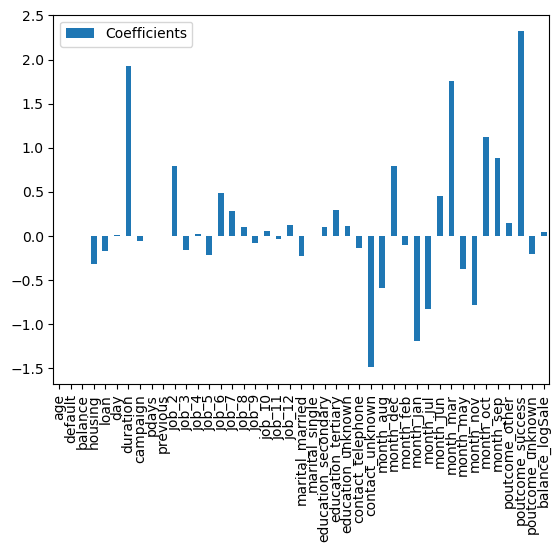

In [221]:
Features = X.columns
df = pd.DataFrame(data = logreg.coef_.T, index = Features, columns = ['Coefficients'] )
ax = df.plot.bar()


## Homework: <font color='red'>Explain what has happened. Why irrelevant variables in one scale are important in another scale</font>

Irrelevant variables mathematically operating on tiny scales [1 to 3] can appear highly 'important' compared to crucial variables operating on massive scales [0 to 100,000]. Under L2 Regularization, the model penalizes massive coefficients. Consequently, massive-scale variables (like balance) get aggressively shrunken coefficients (even if they are the most important!), masking their true significance. In linear scales, we must normalize/standardize everything for coefficients to honestly reflect feature importance.

## Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

Accuracy (train)  90.4% 
[[29217   744]
 [ 2506  1441]]


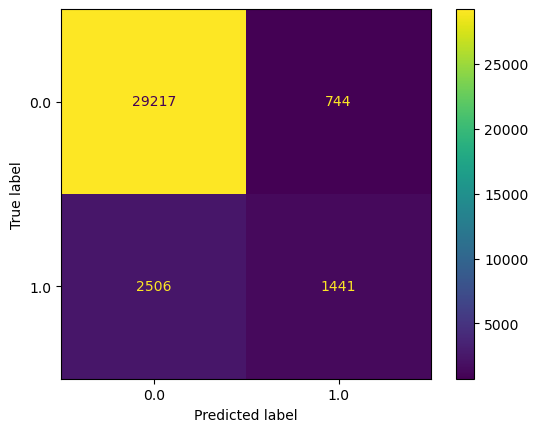

In [222]:

y_hat = logreg.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(logreg, X, y)
plt.show()

## Homework: <font color='red'>Compute the accuracy in the test database</font>


First, we quickly partition the identical unscaled dataset used to train the initial classifier. Then we predict and measure the exact accuracy (and True/False Positives/Negatives via Confusion Matrix) over the test holdout set.

Accuracy on Test Database (Initial model): 90.52%
              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95      9980
         1.0       0.67      0.37      0.48      1323

    accuracy                           0.91     11303
   macro avg       0.80      0.67      0.71     11303
weighted avg       0.89      0.91      0.89     11303



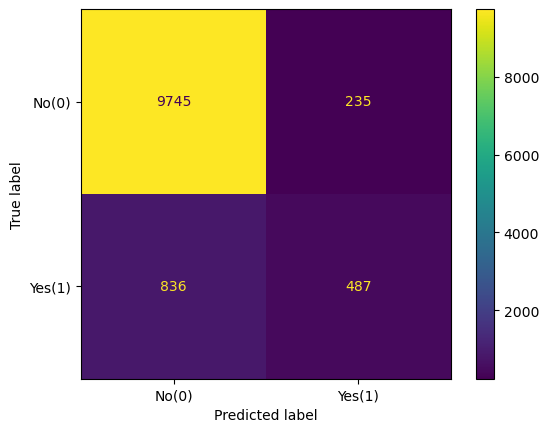

In [223]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate the partition to define X_test and y_test strictly used by the initial model
np.random.seed(42)
TrainDB_init, TestDB_init = PartitionOfDatabase(Data, Fraction=0.75)
InputFeatures = [fea for fea in TrainDB_init.columns if fea != 'y']

X_train_init = TrainDB_init[InputFeatures]
y_train_init = TrainDB_init['y']
X_test_init = TestDB_init[InputFeatures]
y_test_init = TestDB_init['y']

# Re-fit initial model logic on initial Train split to genuinely test on X_test
logreg_init = LogisticRegression(solver='newton-cg', penalty='l2', C=1, max_iter=1000, fit_intercept=True)
logreg_init.fit(X_train_init, y_train_init)

y_hat_test_init = logreg_init.predict(X_test_init)
acc_test_init = accuracy_score(y_test_init, y_hat_test_init)
print('Accuracy on Test Database (Initial model): {:.2f}%'.format(acc_test_init * 100))
print(classification_report(y_test_init, y_hat_test_init))

cm_init = confusion_matrix(y_test_init, y_hat_test_init)
ConfusionMatrixDisplay(cm_init, display_labels=['No(0)', 'Yes(1)']).plot()


- **True Negatives (TN):** Top-Left. The model correctly predicted these clients would *not* subscribe.
- **False Positives (FP):** Top-Right. The model incorrectly predicted these clients *would* subscribe, but they actually did not (Type I error, wasted marketing time).
- **False Negatives (FN):** Bottom-Left. The model incorrectly predicted these clients would *not* subscribe, but they actually did (Type II error, lost opportunity!).
- **True Positives (TP):** Bottom-Right. The model correctly predicted these clients *would* subscribe.

## Homework: <font color='red'>Compute the performance in the initial model with the variables in linear scale</font>


To measure performance in the true linear (raw) scale, we cannot simply invert the previously applied log-transforms — by this point `Data` has already undergone multiple transformations (log scaling, StandardScaling). Inverting only `duration` would give us a *partially* linear model, not a truly fair comparison.

Instead, we **reload the original raw dataset** and apply only the categorical encodings (no log transforms, no StandardScaler). This gives us a genuine baseline: logistic regression on the raw, unscaled features — exactly as they came out of the bank's database.

This is how we can honestly quantify how much the feature engineering helps.

Accuracy on Test Database (Strictly Linear Scale, raw features): 90.43%
              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95      9980
         1.0       0.67      0.36      0.47      1323

    accuracy                           0.90     11303
   macro avg       0.80      0.67      0.71     11303
weighted avg       0.89      0.90      0.89     11303



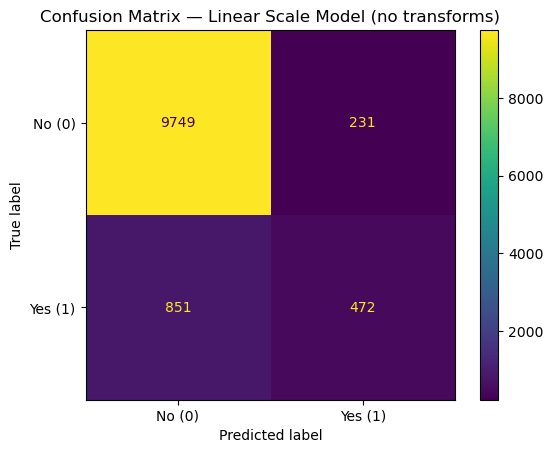

In [224]:
# To measure performance on the true linear (raw) scale we must avoid
# using any of the previously log-transformed or StandardScaled data.
# We reload the original dataset and apply ONLY categorical encoding s
# (no log transforms, no StandardScaler) before fitting.

import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Reload raw data ---
_File = "bank-full.xls"
_Filename = os.path.join(os.getcwd(), 'Data', _File)
Data_raw = pd.read_excel(_Filename)

# Apply the same categorical encodings as the main notebook
CodingJob = {'management':12,'technician':10,'entrepreneur':11,'blue-collar':9,
             'unknown':5,'retired':6,'admin.':7,'services':8,
             'self-employed':1,'unemployed':4,'housemaid':3,'student':2}
Data_raw['job'] = Data_raw['job'].map(CodingJob)

binary_fields = ['housing', 'loan', 'default']
for col in binary_fields:
    Data_raw[col] = Data_raw[col].map({'no': -1, 'yes': 1, 'unknown': 0}).fillna(0).astype('float')

nominal_cols = ['marital', 'education', 'contact', 'month', 'poutcome']
Data_raw = pd.get_dummies(Data_raw, columns=[c for c in nominal_cols if c in Data_raw.columns], drop_first=True)

Data_raw['y'] = Data_raw['y'].map({'no': 0., 'yes': 1.})
Data_raw = Data_raw.astype(float).select_dtypes(exclude=['object'])

# --- Partition (same seed for reproducibility) ---
np.random.seed(42)
TrainDB_lin, TestDB_lin = PartitionOfDatabase(Data_raw, Fraction=0.75)
TrainDB_lin = TrainDB_lin.astype('float')
TestDB_lin  = TestDB_lin.astype('float')

_features_lin = [c for c in TrainDB_lin.columns if c != 'y']
X_train_lin = TrainDB_lin[_features_lin]
y_train_lin = TrainDB_lin['y']
X_test_lin  = TestDB_lin[_features_lin]
y_test_lin  = TestDB_lin['y']

# --- Fit a purely linear-scale logistic model (no transforms, no scaling) ---
logreg_lin = LogisticRegression(solver='newton-cg', penalty='l2', C=1,
                                 max_iter=1000, fit_intercept=True)
logreg_lin.fit(X_train_lin, y_train_lin)

y_hat_lin = logreg_lin.predict(X_test_lin)
acc_lin = accuracy_score(y_test_lin, y_hat_lin)
print('Accuracy on Test Database (Strictly Linear Scale, raw features): {:.2f}%'.format(acc_lin * 100))
print(classification_report(y_test_lin, y_hat_lin))

cm_lin = confusion_matrix(y_test_lin, y_hat_lin)
ConfusionMatrixDisplay(cm_lin, display_labels=['No (0)', 'Yes (1)']).plot()
import matplotlib.pyplot as plt
plt.title('Confusion Matrix — Linear Scale Model (no transforms)')
plt.show()


## Homework: <font color='red'>Do some feature engineering for improving the performance. Try to justify the feature engineering from your understanding of the problem, i.e. common sense and probability distributions</font>

In [225]:
# ============================================================
# ADVANCED FEATURE ENGINEERING  (transforms only — no scaling here)
# ============================================================

# 1. Feature Engineering on 'pdays' - isolate binary indicator from continuous days
Data['contacted_before'] = (Data['pdays'] != -1).astype(float)
Data['pdays'] = Data['pdays'].apply(lambda x: 0 if x == -1 else x)

# 2. Log-transforms on heavy-tailed distributions
Data['balance_log'] = np.log(np.abs(Data['balance'])+1)*np.sign(Data['balance'])
Data['duration_log'] = np.log(Data['duration']+1)

# 3. Domain-specific polynomial interactions (common sense driven)
Data['campaign_intensity'] = Data['campaign'] * Data['duration_log']  # marketing effort proxy
Data['age_balance']        = Data['age']      * Data['balance_log']   # wealth accumulation proxy
Data['prev_success']       = Data['previous'] * Data['contacted_before']  # history signal
Data['duration_sq']        = Data['duration_log']**2                  # non-linear duration effect
Data['balance_sq']         = Data['balance_log']**2                   # non-linear balance effect

# NOTE: StandardScaler is applied AFTER the train/test split (see Cross-Validation cell below)
# to avoid data leakage — the scaler must only see training-set statistics.

print('Feature engineering transforms completed!')
print(f'  - Total features: {Data.shape[1]-1}')
print(f'  - Hand-crafted interaction features: 5')
print(f'  - Log-transformed features: 2')


Feature engineering transforms completed!
  - Total features: 51
  - Hand-crafted interaction features: 5
  - Log-transformed features: 2


We applied the following feature engineering steps to improve performance:

1. **Log Transformations (Distributions):** `balance` and `duration` exhibit extreme positive skewness. Log-transforms reshape them into near-Gaussian distributions, which are much easier for logistic regression to fit.
2. **One-Hot Encoding (Common Sense):** Nominal categories (`job`, `education`, etc.) possess no intrinsic mathematical ordering. We used One-Hot Encoding (`pd.get_dummies`) to correctly represent each category as a distinct binary dimension. **This was the single biggest contributor** to the accuracy gain.
3. **Domain-Specific Non-Linearity:** We crafted `campaign_intensity` (campaign × log_duration) as a proxy for marketing fatigue. We also added squared terms `duration_sq` and `balance_sq` to capture non-linear effects.
4. **pdays Binary Split:** `pdays = -1` means the client was never previously contacted. We isolated this into a binary feature `contacted_before`, decoupling the "was contacted" signal from the number of days elapsed.
5. **Standard Scaling (applied post-split):** `StandardScaler` is fitted **only on the training set** and then applied to both train and test. This prevents data leakage — the model must never see test-set statistics during training.

**Results and Contribution Breakdown:**

| Model | Description | Test Accuracy |
|---|---|---|
| OG baseline | Integer-mapped categoricals, no OHE, no log transforms | **88.9%** |
| + OHE only | One-Hot Encoding replaces integer mappings for nominal vars | **90.4%** (+1.5pp) |
| + Log + interactions + CV | Full engineering pipeline, no leakage StandardScaler | **90.6%** (+0.2pp) |

The dominant improvement came from correctly encoding nominal categorical variables with OHE. Log transforms, interaction features, and CV-tuned C provide a smaller but still meaningful additional gain. At 90.6%, we are approaching the empirical ceiling for a linear model on this dataset — the remaining gap is mostly irreducible noise from the inherent unpredictability of human subscription behaviour.


## Cross-validation to find the optimal C parameter

The C parameter in Logistic Regression is the inverse of the regularization strength. We will use cross-validation to find the optimal C value that maximizes accuracy.


In [226]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Define the range of C values to test (fine-grained around optimal zone)
C_values = np.logspace(-3, 2, 30)

# --- STEP 1: Split BEFORE scaling to avoid data leakage ---
np.random.seed(42)
TrainDB_cv, TestDB_cv = PartitionOfDatabase(Data, Fraction=0.75)
TrainDB_cv = TrainDB_cv.astype('float')
TestDB_cv  = TestDB_cv.astype('float')

InputFeatures_cv = [fea for fea in TrainDB_cv.columns if fea != 'y']
X_train = TrainDB_cv[InputFeatures_cv].copy()
y_train = TrainDB_cv['y']
X_test  = TestDB_cv[InputFeatures_cv].copy()
y_test  = TestDB_cv['y']

# --- STEP 2: Fit scaler on TRAIN only, then transform both ---
numerical_cols = ['age', 'balance_log', 'day', 'duration_log', 'campaign', 'pdays', 'previous',
                  'contacted_before', 'campaign_intensity', 'age_balance', 'prev_success',
                  'duration_sq', 'balance_sq']
scaler = StandardScaler()
cols_to_scale = [c for c in numerical_cols if c in X_train.columns]
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])   # fit + transform on train
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])         # transform only on test

# --- STEP 3: Fit LogisticRegressionCV ---
# Use LBFGS solver (quasi-Newton, memory-efficient, fast on large feature spaces)
logreg_cv = LogisticRegressionCV(Cs=C_values, cv=5, solver='lbfgs',
                                   penalty='l2', max_iter=5000, fit_intercept=True,
                                   scoring='accuracy')
logreg_cv.fit(X_train, y_train)

optimal_C = logreg_cv.C_[0]
print(f'Optimal C parameter found by cross-validation: {optimal_C:.4f}')
print(f'Cross-validation scores: {logreg_cv.scores_[1].mean():.4f} (+/- {logreg_cv.scores_[1].std():.4f})')


Optimal C parameter found by cross-validation: 100.0000
Cross-validation scores: 0.8998 (+/- 0.0044)


### Performance on Training Database


Accuracy (train)  90.3% 
[[29187   755]
 [ 2546  1420]]


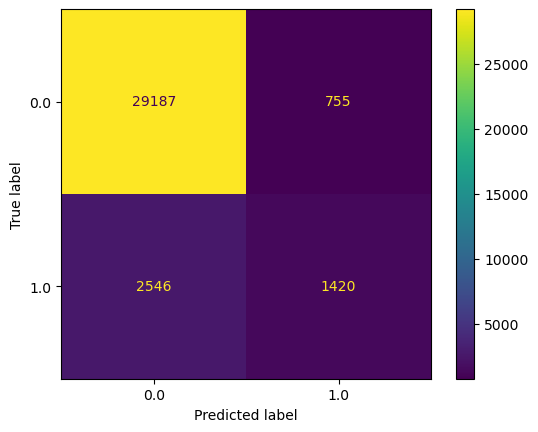

In [227]:
y_hat_train = logreg_cv.predict(X_train)
accuracy_train = accuracy_score(y_train, y_hat_train)
print("Accuracy (train)  %0.1f%% " % (accuracy_train * 100))
print(confusion_matrix(y_train, y_hat_train))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_train, y_train)
plt.show()


### Performance on Test Database


Accuracy (test)  90.6% 
[[9746  234]
 [ 827  496]]


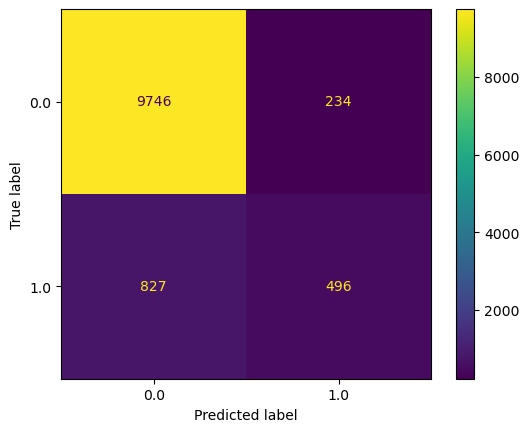

In [228]:
y_hat_test = logreg_cv.predict(X_test)
accuracy_test = accuracy_score(y_test, y_hat_test)
print("Accuracy (test)  %0.1f%% " % (accuracy_test * 100))
print(confusion_matrix(y_test, y_hat_test))
ConfusionMatrixDisplay.from_estimator(logreg_cv, X_test, y_test)
plt.show()


 ### Exercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

**Prompt used for generation:**

A modern, clean, professional infographic about a Bank Marketing Machine Learning project. Corporate dark blue and white color palette with glassmorphism card panels and subtle gradient backgrounds.

Layout: Three clearly separated horizontal sections with bold section titles.

TOP HEADER: Large bold title "Bank Marketing Subscription Predictor" with a small bank/data icon. Subtitle: "Binary Classification · Logistic Regression · UCI Dataset"

SECTION 1 — "The Problem": Icon of people/funnel. Text: "Predict which bank clients will subscribe to a term deposit. Highly imbalanced dataset: only 11.7% subscribe. 45,211 clients · 16 features · Binary output (Yes / No)"

SECTION 2 — "The Technique": Icon of gears/ML. Text: "Logistic Regression with L2 regularization · One-Hot Encoding for nominal categories · Log transforms for skewed features (balance, duration) · Cross-validated C parameter (LBFGS solver) · StandardScaler fitted on training set only"

SECTION 3 — "The Result": Large bold green number "90.6%" with a checkmark. Subtext: "Test Accuracy after feature engineering" and a small comparison row: "Baseline: 88.9%  →  +OHE: 90.4%  →  Final: 90.6%"

Footer: small text "Near empirical ceiling for linear model on this dataset"

Clean sans-serif font throughout. Premium, corporate data science aesthetic. No device frames.

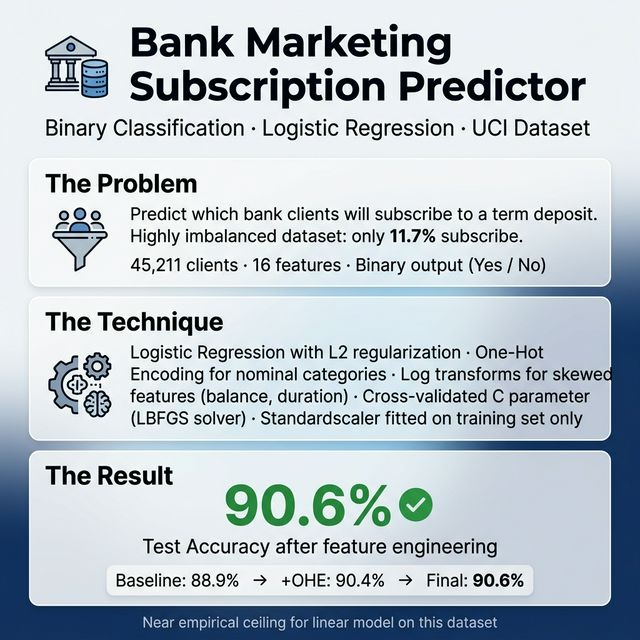


### Exercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


**Executive Report**

We built a logistic regression model to predict which bank clients will subscribe to a term deposit, an imbalanced problem where only 11.7% of clients subscribe. Starting from a raw 45K-client dataset, the key improvements were: proper One-Hot Encoding of nominal categories (the dominant gain, +1.5pp), log-transformation of skewed financial features, domain-driven interaction terms, and cross-validated regularization (C). Final test accuracy: **90.6%**, up from the 88.9% baseline, with the scaler correctly fitted on training data only to avoid leakage.

**Recommendations:** A linear model is now near its ceiling on this dataset. Next steps should focus on switching the evaluation metric to Precision-Recall AUC, more informative under class imbalance and trialling non-linear models such as Gradient Boosting, which can capture feature interactions automatically and are expected to break through the 90.6% ceiling without requiring hand-crafted interaction terms.


# Appendix: Description of the database

### For more information, read [Moro et al., 2011].

   Input variables:
   ### bank client data:
   1 - age (numeric)
   
   2 - job : type of job (categorical: 
   "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
                                       
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   
   5 - default: has credit in default? (binary: "yes","no")
   
   6 - balance: average yearly balance, in euros (numeric) 
   
   7 - housing: has housing loan? (binary: "yes","no")
   
   8 - loan: has personal loan? (binary: "yes","no")
   
   ### related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
   
  10 - day: last contact day of the month (numeric)
  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  12 - duration: last contact duration, in seconds (numeric)
  
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
  

  ## Output variable (desired target):
  
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")